In [6]:
!pip install pandas numpy nltk textblob vaderSentiment wordcloud matplotlib seaborn

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 779.1 kB/s  0:00:00

   -------------------------- ------------- 2/3 [textblob]
   -------------------------- ------------- 2/3 [textblob]
   ---------------------------------------- 3/3 [textblob]



In [7]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [8]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Prachi
[nltk_data]     Landge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Prachi
[nltk_data]     Landge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Prachi
[nltk_data]     Landge\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
df = pd.read_csv(r"C:\Users\Prachi Landge\Downloads\sentimentdataset.csv")

In [13]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [15]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

In [16]:
text_column = "Text"

In [17]:
df = df.dropna(subset=[text_column])

In [18]:
df[text_column] = df[text_column].str.lower()

In [19]:
def clean_text(text):
    
    text = re.sub(r"http\S+", "", text)
    
    text = re.sub(r"@\w+", "", text)
    
    text = re.sub(r"#", "", text)
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [20]:
df["Cleaned_Text"] = df[text_column].apply(clean_text)

In [83]:
df["Tokens"] = df["Cleaned_Text"].apply(word_tokenize)

In [84]:
stop_words = set(stopwords.words('english'))

df["Tokens_No_Stopwords"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [85]:
stemmer = PorterStemmer()

df["Stemmed"] = df["Tokens_No_Stopwords"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [86]:
lemmatizer = WordNetLemmatizer()

df["Lemmatized"] = df["Tokens_No_Stopwords"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [87]:
df["Processed_Text"] = df["Lemmatized"].apply(lambda x: " ".join(x))

In [88]:
def get_textblob_sentiment(text):
    
    analysis = TextBlob(text)
    
    polarity = analysis.sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    
    elif polarity < 0:
        return "Negative"
    
    else:
        return "Neutral"

In [89]:
df["TextBlob_Sentiment"] = df["Processed_Text"].apply(get_textblob_sentiment)

In [90]:
analyzer = SentimentIntensityAnalyzer()

In [91]:
def get_vader_sentiment(text):
    
    score = analyzer.polarity_scores(text)
    
    compound = score['compound']
    
    if compound >= 0.05:
        return "Positive"
    
    elif compound <= -0.05:
        return "Negative"
    
    else:
        return "Neutral"

In [92]:
df["VADER_Sentiment"] = df["Processed_Text"].apply(get_vader_sentiment)

In [93]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,...,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score,Mapped_Sentiment
0,0,enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,...,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]",enjoying beautiful day park,Positive,Positive,0.8074,Positive
1,1,traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,...,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]","[traffic, terribl, morn]","[traffic, terrible, morning]",traffic terrible morning,Negative,Negative,-0.4767,Negative
2,2,just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,...,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]","[finish, amaz, workout]","[finished, amazing, workout]",finished amazing workout,Positive,Positive,0.5859,Positive
3,3,excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,...,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]",excited upcoming weekend getaway,Positive,Positive,0.3400,Positive
4,4,trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,...,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]",trying new recipe dinner tonight,Positive,Neutral,0.0000,Neutral


In [94]:
df["VADER_Sentiment"].value_counts()

VADER_Sentiment
Positive    464
Negative    184
Neutral      84
Name: count, dtype: int64

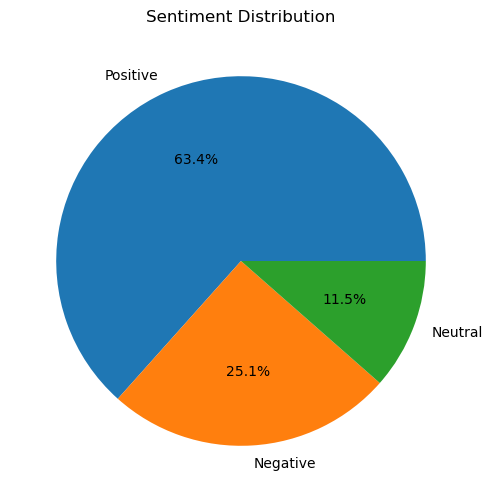

In [33]:
sentiment_counts = df["VADER_Sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")

plt.show()

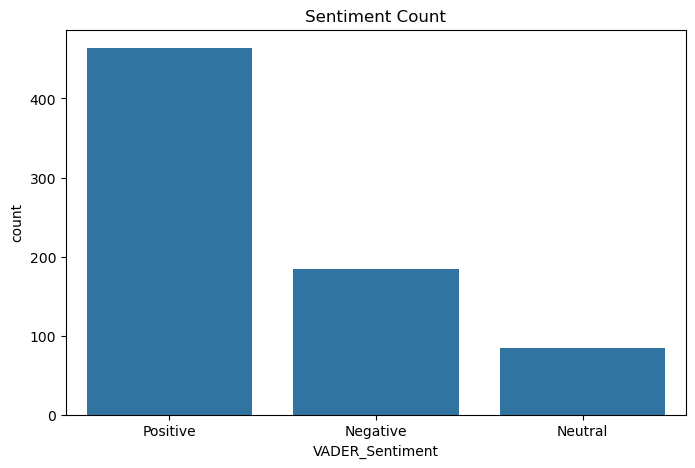

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["VADER_Sentiment"]
)

plt.title("Sentiment Count")

plt.show()

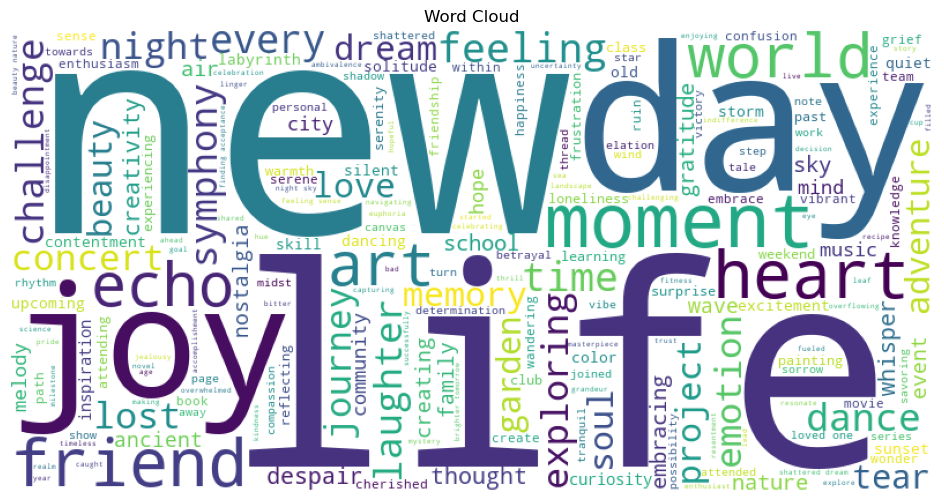

In [35]:
all_words = " ".join(df["Processed_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

In [36]:
from collections import Counter

In [37]:
all_tokens = []

for words in df["Tokens_No_Stopwords"]:
    all_tokens.extend(words)

In [38]:
common_words = Counter(all_tokens).most_common(10)

common_words

[('new', 43),
 ('like', 27),
 ('day', 26),
 ('feeling', 26),
 ('dreams', 25),
 ('laughter', 24),
 ('heart', 24),
 ('night', 23),
 ('joy', 23),
 ('life', 22)]

In [39]:
words = [word[0] for word in common_words]

counts = [word[1] for word in common_words]

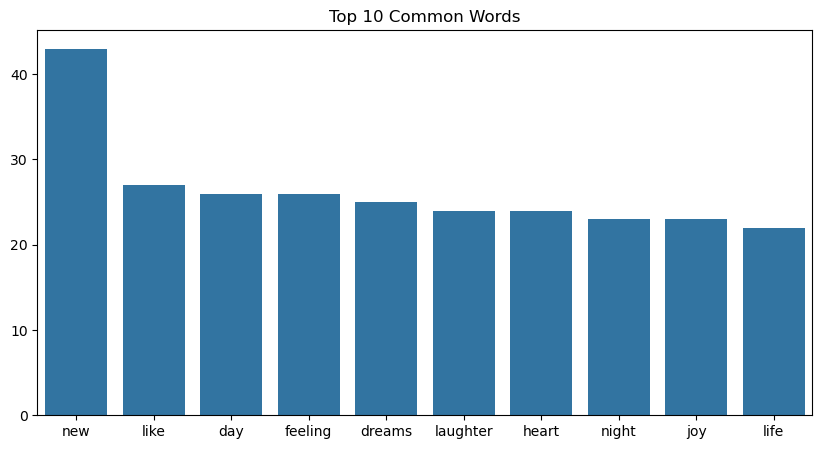

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=words,
    y=counts
)

plt.title("Top 10 Common Words")

plt.show()

In [41]:
df.to_csv("processed_sentiment_data.csv", index=False)

In [42]:
from sklearn.metrics import accuracy_score

In [45]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour', 'Cleaned_Text', 'Tokens', 'Tokens_No_Stopwords',
       'Stemmed', 'Lemmatized', 'Processed_Text', 'TextBlob_Sentiment',
       'VADER_Sentiment'],
      dtype='object')


In [48]:
def sentiment_score(text):
    return analyzer.polarity_scores(text)['compound']

In [49]:
df["Sentiment_Score"] = df["Processed_Text"].apply(sentiment_score)

In [50]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [51]:
trend = df.groupby(
    df["Timestamp"].dt.date
)["Sentiment_Score"].mean()

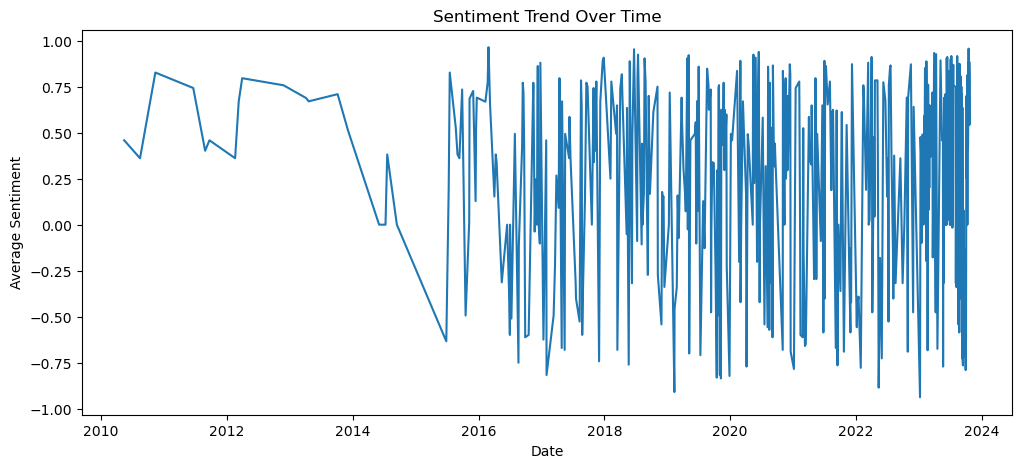

In [52]:
plt.figure(figsize=(12,5))

trend.plot()

plt.title("Sentiment Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Average Sentiment")

plt.show()

In [54]:
print(df["Sentiment"].unique())

[' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimidation    ' ' Helplessness    '
 ' 

In [55]:
print(df["VADER_Sentiment"].unique())

['Positive' 'Negative' 'Neutral']


In [56]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,...,Hour,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score
0,0,0,enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,...,12,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]",enjoying beautiful day park,Positive,Positive,0.8074
1,1,1,traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,...,8,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]","[traffic, terribl, morn]","[traffic, terrible, morning]",traffic terrible morning,Negative,Negative,-0.4767
2,2,2,just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,...,15,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]","[finish, amaz, workout]","[finished, amazing, workout]",finished amazing workout,Positive,Positive,0.5859
3,3,3,excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,...,18,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]",excited upcoming weekend getaway,Positive,Positive,0.3400
4,4,4,trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,...,19,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]",trying new recipe dinner tonight,Positive,Neutral,0.0000


In [57]:
positive_words = [
    'Positive', 'Happiness', 'Joy', 'Love', 'Amusement',
    'Enjoyment', 'Admiration', 'Affection', 'Awe',
    'Acceptance', 'Adoration', 'Anticipation',
    'Calmness', 'Excitement', 'Kind', 'Pride',
    'Elation', 'Euphoria', 'Contentment', 'Serenity',
    'Gratitude', 'Hope', 'Empowerment', 'Compassion',
    'Tenderness', 'Enthusiasm', 'Fulfillment',
    'Reverence', 'Curiosity', 'Determination',
    'Zest', 'Hopeful', 'Proud', 'Grateful',
    'Empathetic', 'Compassionate', 'Playful',
    'Free-spirited', 'Inspired', 'Confident',
    'Thrill', 'Motivation', 'Blessed',
    'Appreciation', 'Confidence', 'Accomplishment',
    'Wonderment', 'Optimism', 'Enchantment',
    'Creativity', 'Radiance', 'Adventure',
    'Resilience', 'Marvel', 'Friendship',
    'Success', 'Celebration', 'Triumph',
    'Heartwarming', 'Breakthrough', 'Harmony',
    'Relief', 'Happy'
]

In [58]:
negative_words = [
    'Negative', 'Anger', 'Fear', 'Sadness',
    'Disgust', 'Disappointed', 'Bitter',
    'Shame', 'Despair', 'Grief',
    'Loneliness', 'Jealousy', 'Resentment',
    'Frustration', 'Boredom', 'Anxiety',
    'Intimidation', 'Helplessness',
    'Envy', 'Regret', 'Melancholy',
    'Fearful', 'Apprehensive',
    'Overwhelmed', 'Jealous',
    'Devastated', 'Frustrated',
    'Dismissive', 'Heartbreak',
    'Betrayal', 'Suffering',
    'EmotionalStorm', 'Isolation',
    'Disappointment', 'LostLove',
    'Exhaustion', 'Sorrow',
    'Darkness', 'Desperation',
    'Ruins', 'Desolation',
    'Loss', 'Heartache',
    'Obstacle', 'Pressure',
    'Miscalculation', 'Embarrassed',
    'Sad', 'Hate', 'Bad'
]

In [59]:
def map_sentiment(sentiment):
    
    sentiment = str(sentiment).strip()
    
    if sentiment in positive_words:
        return "Positive"
    
    elif sentiment in negative_words:
        return "Negative"
    
    else:
        return "Neutral"

In [60]:
df["Mapped_Sentiment"] = df["Sentiment"].apply(map_sentiment)

In [61]:
df[["Sentiment", "Mapped_Sentiment"]].head(20)

,Sentiment,Mapped_Sentiment
0,Positive,Positive
1,Negative,Negative
2,Positive,Positive
3,Positive,Positive
4,Neutral,Neutral
5,Positive,Positive
6,Positive,Positive
7,Positive,Positive
8,Negative,Negative
9,Neutral,Neutral


In [62]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,...,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score,Mapped_Sentiment
0,0,0,enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,...,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]",enjoying beautiful day park,Positive,Positive,0.8074,Positive
1,1,1,traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,...,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]","[traffic, terribl, morn]","[traffic, terrible, morning]",traffic terrible morning,Negative,Negative,-0.4767,Negative
2,2,2,just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,...,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]","[finish, amaz, workout]","[finished, amazing, workout]",finished amazing workout,Positive,Positive,0.5859,Positive
3,3,3,excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,...,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]",excited upcoming weekend getaway,Positive,Positive,0.3400,Positive
4,4,4,trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,...,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]",trying new recipe dinner tonight,Positive,Neutral,0.0000,Neutral


In [63]:
from sklearn.metrics import accuracy_score

In [64]:
accuracy = accuracy_score(
    df["Mapped_Sentiment"],
    df["VADER_Sentiment"]
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 69.4 %


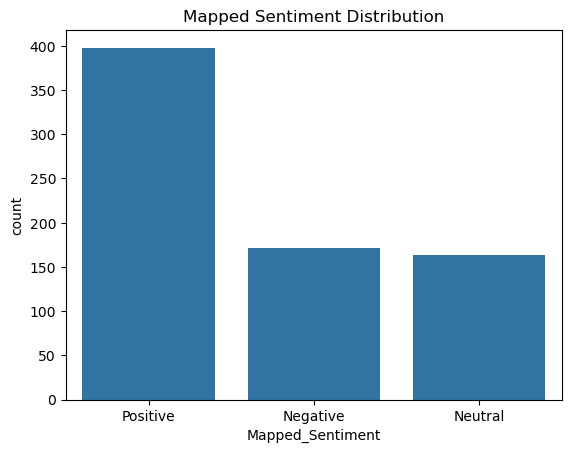

In [65]:
sns.countplot(x="Mapped_Sentiment", data=df)

plt.title("Mapped Sentiment Distribution")

plt.show()

In [66]:
df[["Text"]].head(5)

,Text
0,enjoying a beautiful day at the park! ...
1,traffic was terrible this morning. ...
2,just finished an amazing workout! 💪 ...
3,excited about the upcoming weekend getaway! ...
4,trying out a new recipe for dinner tonight. ...


In [67]:
df[["Text", "Cleaned_Text"]].head(5)

,Text,Cleaned_Text
0,enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park
1,traffic was terrible this morning. ...,traffic was terrible this morning
2,just finished an amazing workout! 💪 ...,just finished an amazing workout
3,excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway
4,trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight


In [68]:
df[["Cleaned_Text", "Tokens"]].head(5)

,Cleaned_Text,Tokens
0,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]"
1,traffic was terrible this morning,"[traffic, was, terrible, this, morning]"
2,just finished an amazing workout,"[just, finished, an, amazing, workout]"
3,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]"
4,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton..."


In [69]:
df[["Tokens", "Tokens_No_Stopwords"]].head(5)

,Tokens,Tokens_No_Stopwords
0,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]"
1,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]"
2,"[just, finished, an, amazing, workout]","[finished, amazing, workout]"
3,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]"


In [70]:
df[["Tokens_No_Stopwords", "Stemmed"]].head(5)

,Tokens_No_Stopwords,Stemmed
0,"[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]"
1,"[traffic, terrible, morning]","[traffic, terribl, morn]"
2,"[finished, amazing, workout]","[finish, amaz, workout]"
3,"[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]"
4,"[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]"


In [71]:
df[[
    "Processed_Text",
    "VADER_Sentiment",
    "TextBlob_Sentiment"
]].head(10)

,Processed_Text,VADER_Sentiment,TextBlob_Sentiment
0,enjoying beautiful day park,Positive,Positive
1,traffic terrible morning,Negative,Negative
2,finished amazing workout,Positive,Positive
3,excited upcoming weekend getaway,Positive,Positive
4,trying new recipe dinner tonight,Neutral,Positive
5,feeling grateful little thing life,Positive,Negative
6,rainy day call cozy blanket hot cocoa,Negative,Positive
7,new movie release mustwatch,Neutral,Positive
8,political discussion heating timeline,Neutral,Neutral
9,missing summer vibe beach day,Negative,Negative


In [72]:
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 69.4 %


In [95]:
df.isnull().sum()

Unnamed: 0.1           0
Text                   0
Sentiment              0
Timestamp              0
User                   0
Platform               0
Hashtags               0
Retweets               0
Likes                  0
Country                0
Year                   0
Month                  0
Day                    0
Hour                   0
Cleaned_Text           0
Tokens                 0
Tokens_No_Stopwords    0
Stemmed                0
Lemmatized             0
Processed_Text         0
TextBlob_Sentiment     0
VADER_Sentiment        0
Sentiment_Score        0
Mapped_Sentiment       0
dtype: int64

In [96]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,...,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score,Mapped_Sentiment
0,0,enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,...,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]",enjoying beautiful day park,Positive,Positive,0.8074,Positive
1,1,traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,...,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]","[traffic, terribl, morn]","[traffic, terrible, morning]",traffic terrible morning,Negative,Negative,-0.4767,Negative
2,2,just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,...,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]","[finish, amaz, workout]","[finished, amazing, workout]",finished amazing workout,Positive,Positive,0.5859,Positive
3,3,excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,...,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]",excited upcoming weekend getaway,Positive,Positive,0.3400,Positive
4,4,trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,...,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]",trying new recipe dinner tonight,Positive,Neutral,0.0000,Neutral


In [97]:
df.drop(
    columns=["Unnamed: 0.1"],
    inplace=True
)

In [98]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,...,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score,Mapped_Sentiment
0,enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,...,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]",enjoying beautiful day park,Positive,Positive,0.8074,Positive
1,traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,...,traffic was terrible this morning,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]","[traffic, terribl, morn]","[traffic, terrible, morning]",traffic terrible morning,Negative,Negative,-0.4767,Negative
2,just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,...,just finished an amazing workout,"[just, finished, an, amazing, workout]","[finished, amazing, workout]","[finish, amaz, workout]","[finished, amazing, workout]",finished amazing workout,Positive,Positive,0.5859,Positive
3,excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,...,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]",excited upcoming weekend getaway,Positive,Positive,0.3400,Positive
4,trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,...,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]",trying new recipe dinner tonight,Positive,Neutral,0.0000,Neutral


In [99]:
df.tail(10)

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,...,Cleaned_Text,Tokens,Tokens_No_Stopwords,Stemmed,Lemmatized,Processed_Text,TextBlob_Sentiment,VADER_Sentiment,Sentiment_Score,Mapped_Sentiment
722,winning a friendly sports competition against ...,Happy,2023-10-20 14:15:00,SportsVictoryHighSchool,Twitter,#SportsTriumph #HighSchoolAthletics,26.0,50.0,USA,2023,...,winning a friendly sports competition against ...,"[winning, a, friendly, sports, competition, ag...","[winning, friendly, sports, competition, rival...","[win, friendli, sport, competit, rival, school...","[winning, friendly, sport, competition, rival,...",winning friendly sport competition rival schoo...,Positive,Positive,0.7650,Positive
723,receiving a heartfelt letter from a pen pal in...,Happy,2023-10-21 17:30:00,PenPalConnectionHighSchool,Facebook,#GlobalFriendship #HighSchoolCorrespondence,23.0,45.0,Canada,2023,...,receiving a heartfelt letter from a pen pal in...,"[receiving, a, heartfelt, letter, from, a, pen...","[receiving, heartfelt, letter, pen, pal, anoth...","[receiv, heartfelt, letter, pen, pal, anoth, c...","[receiving, heartfelt, letter, pen, pal, anoth...",receiving heartfelt letter pen pal another cou...,Neutral,Positive,0.5423,Positive
724,creating a beautiful mural with fellow art ent...,Happy,2023-10-22 20:45:00,MuralCreationHighSchool,Instagram,#ArtCollaboration #HighSchoolCreativity,22.0,43.0,UK,2023,...,creating a beautiful mural with fellow art ent...,"[creating, a, beautiful, mural, with, fellow, ...","[creating, beautiful, mural, fellow, art, enth...","[creat, beauti, mural, fellow, art, enthusiast...","[creating, beautiful, mural, fellow, art, enth...",creating beautiful mural fellow art enthusiast...,Positive,Positive,0.8807,Positive
725,participating in a school-wide art exhibition....,Happy,2015-11-10 16:45:00,ArtExhibitionJoyHighSchool,Instagram,#ArtisticExpression #HighSchoolCreativity,23.0,44.0,USA,2015,...,participating in a schoolwide art exhibition w...,"[participating, in, a, schoolwide, art, exhibi...","[participating, schoolwide, art, exhibition, w...","[particip, schoolwid, art, exhibit, wit, creat...","[participating, schoolwide, art, exhibition, w...",participating schoolwide art exhibition witnes...,Positive,Positive,0.7351,Positive
726,achieving a personal best in a track and field...,Happy,2016-09-14 12:30:00,TrackFieldSuccessHighSchool,Twitter,#AthleticAchievement #HighSchoolSports,26.0,51.0,Canada,2016,...,achieving a personal best in a track and field...,"[achieving, a, personal, best, in, a, track, a...","[achieving, personal, best, track, field, comp...","[achiev, person, best, track, field, competit,...","[achieving, personal, best, track, field, comp...",achieving personal best track field competitio...,Positive,Positive,0.7717,Positive
727,collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,...,collaborating on a science project that receiv...,"[collaborating, on, a, science, project, that,...","[collaborating, science, project, received, re...","[collabor, scienc, project, receiv, recognit, ...","[collaborating, science, project, received, re...",collaborating science project received recogni...,Positive,Positive,0.7845,Positive
728,attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,...,attending a surprise birthday party organized ...,"[attending, a, surprise, birthday, party, orga...","[attending, surprise, birthday, party, organiz...","[attend, surpris, birthday, parti, organ, frie...","[attending, surprise, birthday, party, organiz...",attending surprise birthday party organized fr...,Positive,Positive,0.9538,Positive
729,successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,

**Machine Learning**

In [101]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [102]:
X = df["Processed_Text"]

In [103]:
y = df["Mapped_Sentiment"]

In [104]:
vectorizer = TfidfVectorizer()

In [105]:
X_vectorized = vectorizer.fit_transform(X)

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [110]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [111]:
y_pred = model.predict(X_test)

In [112]:
accuracy = accuracy_score(y_test, y_pred)

print("ML Accuracy:", accuracy)

ML Accuracy: 0.5918367346938775


In [113]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.90      0.23      0.37        39
     Neutral       1.00      0.09      0.17        33
    Positive       0.56      1.00      0.72        75

    accuracy                           0.59       147
   macro avg       0.82      0.44      0.42       147
weighted avg       0.75      0.59      0.50       147



In [114]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 9  0 30]
 [ 1  3 29]
 [ 0  0 75]]


In [115]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

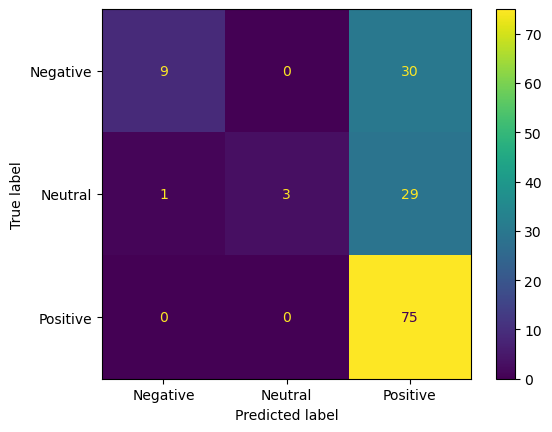

In [116]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [117]:
df["ML_Prediction"] = model.predict(X_vectorized)

In [118]:
accuracy_score(
    df["Mapped_Sentiment"],
    df["ML_Prediction"]
)

0.8592896174863388

In [119]:
accuracy_score(
    df["Mapped_Sentiment"],
    df["VADER_Sentiment"]
)

0.6939890710382514

In [120]:
accuracy_score(
    df["Mapped_Sentiment"],
    df["TextBlob_Sentiment"]
)

0.4918032786885246

In [121]:
df.to_csv(
    "final_processed_sentiment_dataset.csv",
    index=False
)